In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def signal(t):
    return (np.sin(2 * np.pi * 10 * t) + np.sin(2 * np.pi * 100 * t))

In [3]:
def show_noisy_signal():
    t = np.linspace(0, 1, 1000)
    x = np.sin(2 * np.pi * 100 * t)
    plt.plot(t, x)
    plt.title("Noisy signal")
    plt.xlabel("T")
    plt.ylabel("x(t)")
    plt.grid(True)

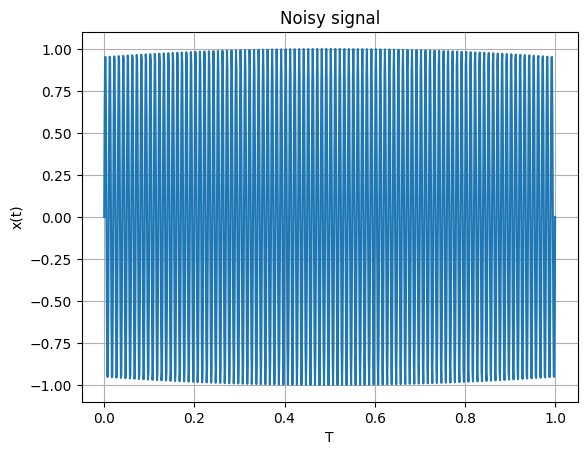

In [4]:
show_noisy_signal()

In [5]:
def ideal_impulse_response(fc, N):
    M = N - 1
    hd = np.zeros(N)
    for n in range(N):
        if n == M / 2:
            hd[n] = 2 * fc
        else:
            hd[n] = (np.sin(2 * np.pi * fc * (n - M / 2))) / (np.pi * (n - M / 2))
    return hd

In [6]:
def hamming_window(N):
    M = N - 1
    w = np.zeros(N)
    for n in range(N):
        w[n] = 0.54 - .46 * np.cos((2 * np.pi * n) / M)
    return w

In [7]:
fc = 20 / 1000
N = 21
hd = ideal_impulse_response(fc, N)
hd

array([0.03027307, 0.03200171, 0.03359474, 0.03503743, 0.03631635,
       0.03741957, 0.03833674, 0.03905923, 0.03958022, 0.03989481,
       0.04      , 0.03989481, 0.03958022, 0.03905923, 0.03833674,
       0.03741957, 0.03631635, 0.03503743, 0.03359474, 0.03200171,
       0.03027307])

In [8]:
wn = hamming_window(N)
wn

array([0.08      , 0.102514  , 0.16785218, 0.26961878, 0.39785218,
       0.54      , 0.68214782, 0.81038122, 0.91214782, 0.977486  ,
       1.        , 0.977486  , 0.91214782, 0.81038122, 0.68214782,
       0.54      , 0.39785218, 0.26961878, 0.16785218, 0.102514  ,
       0.08      ])

In [9]:
h = hd * wn
h

array([0.00242185, 0.00328062, 0.00563895, 0.00944675, 0.01444854,
       0.02020657, 0.02615132, 0.03165286, 0.03610302, 0.03899662,
       0.04      , 0.03899662, 0.03610302, 0.03165286, 0.02615132,
       0.02020657, 0.01444854, 0.00944675, 0.00563895, 0.00328062,
       0.00242185])

In [10]:
def convolution(x, h):
    N = len(x)
    M = len(h)
    y = np.zeros(N + M - 1)
    for n in range(N + M + 1):
        for k in range(N):
            if 0 <= n - k < M:
                y[n] += x[k] * h[n - k]
    return y

In [11]:
t = np.linspace(0, 1, 1000)
x = signal(t)
y = convolution(x, h)

In [12]:
y

array([ 0.00000000e+00,  1.57697807e-03,  4.74426047e-03, ...,
       -4.74426047e-03, -1.57697807e-03,  3.58307166e-18])

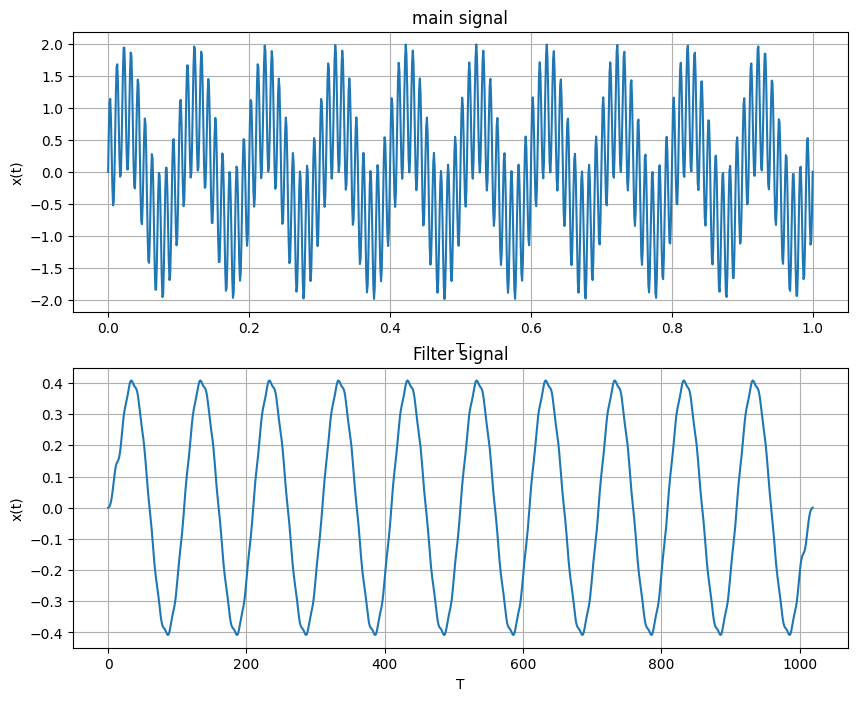

In [15]:
def plot():
    t = np.linspace(0, 1, 1000)
    x = signal(t)
    plt.figure(figsize=(10, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(t, x)
    plt.title("main signal")
    plt.xlabel("T")
    plt.ylabel("x(t)")
    plt.grid(True)
    
    plt.subplot(2, 1, 2)
    plt.plot(y)
    plt.title("Filter signal")
    plt.xlabel("T")
    plt.ylabel("x(t)")
    plt.grid(True)
plot()